# Importing dependencies

In [142]:
import pandas as pd
import torch
from torch import nn
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Preparing Datset

link: https://www.kaggle.com/datasets/olcaybolat1/dermatology-dataset-classification

In [143]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [144]:
data = pd.read_csv('/content/dermatology_database_1.csv')
df =pd.DataFrame(data)
print(df.head(5))


   erythema  scaling  definite_borders  itching  koebner_phenomenon  \
0         2        2                 0        3                   0   
1         3        3                 3        2                   1   
2         2        1                 2        3                   1   
3         2        2                 2        0                   0   
4         2        3                 2        2                   2   

   polygonal_papules  follicular_papules  oral_mucosal_involvement  \
0                  0                   0                         0   
1                  0                   0                         0   
2                  3                   0                         3   
3                  0                   0                         0   
4                  2                   0                         2   

   knee_and_elbow_involvement  scalp_involvement  ...  \
0                           1                  0  ...   
1                           1         

In [145]:
columns_with_zeros = df.columns[(df == 0).any()].tolist()
print("Columns containing zeros:", columns_with_zeros)

Columns containing zeros: ['erythema', 'scaling', 'definite_borders', 'itching', 'koebner_phenomenon', 'polygonal_papules', 'follicular_papules', 'oral_mucosal_involvement', 'knee_and_elbow_involvement', 'scalp_involvement', 'family_history', 'melanin_incontinence', 'eosinophils_infiltrate', 'PNL_infiltrate', 'fibrosis_papillary_dermis', 'exocytosis', 'acanthosis', 'hyperkeratosis', 'parakeratosis', 'clubbing_rete_ridges', 'elongation_rete_ridges', 'thinning_suprapapillary_epidermis', 'spongiform_pustule', 'munro_microabcess', 'focal_hypergranulosis', 'disappearance_granular_layer', 'vacuolisation_damage_basal_layer', 'spongiosis', 'saw_tooth_appearance_retes', 'follicular_horn_plug', 'perifollicular_parakeratosis', 'inflammatory_mononuclear_infiltrate', 'band_like_infiltrate']


In [146]:
categorical_columns = df.select_dtypes(include=['object', 'category']).columns.tolist()
print("Categorical columns:", categorical_columns)

Categorical columns: ['age']


In [147]:
print(df['age'].dtype)  # Check the data type of the column
print(df['age'].unique())  # View unique values in the column
df['age'] = df['age'].replace('?', 13)
print(df['age'].unique())  # View unique values in the column

object
['55' '8' '26' '40' '45' '41' '18' '57' '22' '30' '20' '21' '10' '65' '38'
 '23' '17' '51' '42' '44' '33' '43' '50' '34' '?' '15' '46' '62' '35' '48'
 '12' '52' '60' '32' '19' '29' '25' '36' '13' '27' '31' '28' '64' '39'
 '47' '16' '0' '7' '70' '37' '61' '67' '56' '53' '24' '58' '49' '63' '68'
 '9' '75']
['55' '8' '26' '40' '45' '41' '18' '57' '22' '30' '20' '21' '10' '65' '38'
 '23' '17' '51' '42' '44' '33' '43' '50' '34' 13 '15' '46' '62' '35' '48'
 '12' '52' '60' '32' '19' '29' '25' '36' '13' '27' '31' '28' '64' '39'
 '47' '16' '0' '7' '70' '37' '61' '67' '56' '53' '24' '58' '49' '63' '68'
 '9' '75']


In [148]:
columns_to_drop = ['class']  # Replace with the names of the columns you want to drop
X = df.drop(columns=columns_to_drop, axis=1)
Y = df['class']
X['age'] = X['age'].astype('int64') #  as  X contains the data as object because of the categorical
print(X)

print(Y.head(5))

     erythema  scaling  definite_borders  itching  koebner_phenomenon  \
0           2        2                 0        3                   0   
1           3        3                 3        2                   1   
2           2        1                 2        3                   1   
3           2        2                 2        0                   0   
4           2        3                 2        2                   2   
..        ...      ...               ...      ...                 ...   
361         2        1                 1        0                   1   
362         3        2                 1        0                   1   
363         3        2                 2        2                   3   
364         2        1                 3        1                   2   
365         3        2                 2        0                   0   

     polygonal_papules  follicular_papules  oral_mucosal_involvement  \
0                    0                   0         

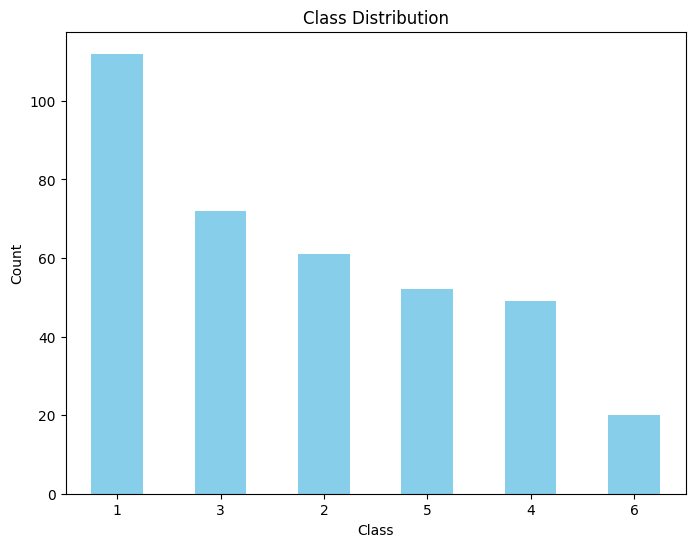

In [149]:
import matplotlib.pyplot as plt

# Count the occurrences of each class
class_counts = Y.value_counts()

# Plot the bar graph
plt.figure(figsize=(8, 6))
class_counts.plot(kind='bar', color='skyblue')
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()


In [150]:
print(X.dtypes)  # For DataFrame X
print('\n')
print(Y.dtypes)  # For DataFrame Y

erythema                               int64
scaling                                int64
definite_borders                       int64
itching                                int64
koebner_phenomenon                     int64
polygonal_papules                      int64
follicular_papules                     int64
oral_mucosal_involvement               int64
knee_and_elbow_involvement             int64
scalp_involvement                      int64
family_history                         int64
melanin_incontinence                   int64
eosinophils_infiltrate                 int64
PNL_infiltrate                         int64
fibrosis_papillary_dermis              int64
exocytosis                             int64
acanthosis                             int64
hyperkeratosis                         int64
parakeratosis                          int64
clubbing_rete_ridges                   int64
elongation_rete_ridges                 int64
thinning_suprapapillary_epidermis      int64
spongiform

In [151]:
## converting to tensors
X = torch.tensor(X.values, dtype = torch.float32)
Y = torch.tensor(Y.values, dtype = torch.float32)

## Visualization:
Before visualizing, identify which features are:

* Numerical: Continuous values like age, height, etc.
* Categorical: Discrete values like gender, class, etc.

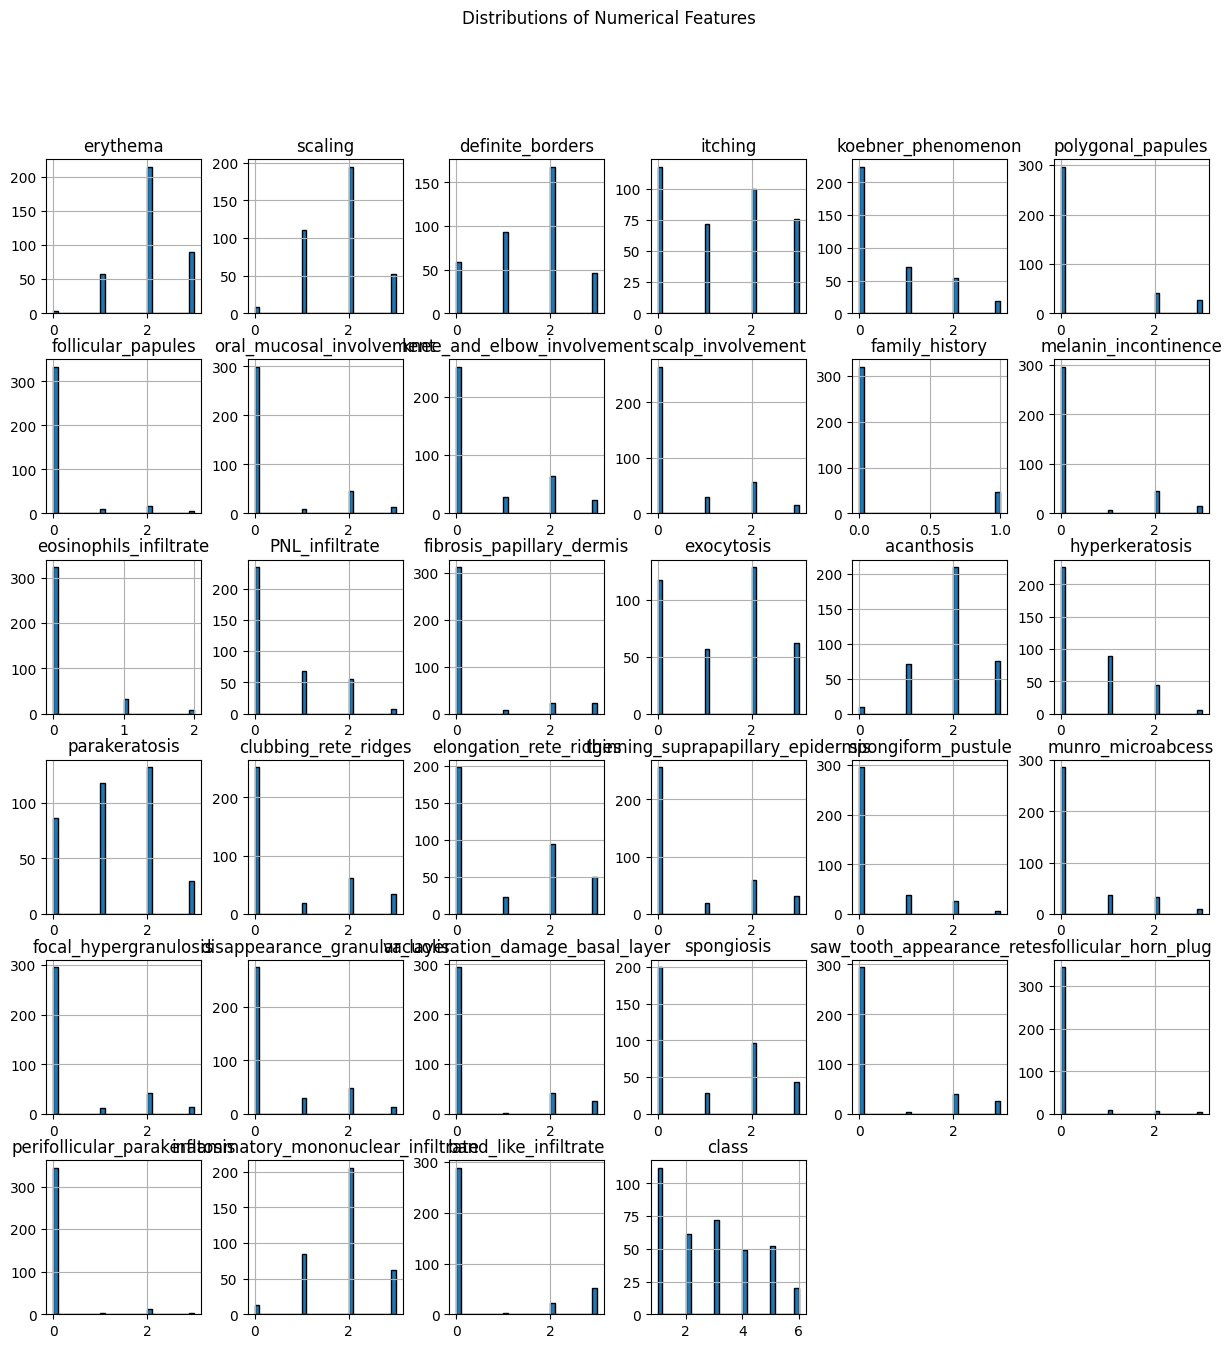

In [152]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot numerical feature distributions
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
df[numerical_features].hist(figsize=(15, 15), bins=30, edgecolor='black')
plt.suptitle("Distributions of Numerical Features")
plt.show()

In [153]:
## train test spilt
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 42 )

In [154]:
## Device Agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

X_train, x_test = X_train.to(device), X_test.to(device)
Y_train, Y_test = Y_train.to(device), Y_test.to(device)

## Model

In [155]:
class Derma(nn.Module):
  def __init__(self,input_units, hidden_units, output_units):
    super().__init__()
    self.layers = nn.Sequential(
        nn.Linear(in_features = input_units, out_features = hidden_units),
        nn.ReLU(),
        nn.Linear(in_features = hidden_units, out_features = hidden_units),
        nn.ReLU(),
        nn.Linear(in_features = hidden_units, out_features = output_units)
    )

  def forward(self, x):
    return self.layers(x)



In [156]:
num_classes = len(Y_train.unique())
num_classes

6

In [157]:
## model instances
input_units = 34
hidden_units = 64
output_units = num_classes
model_darma = Derma(input_units, hidden_units, output_units).to(device)
model_darma

Derma(
  (layers): Sequential(
    (0): Linear(in_features=34, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=6, bias=True)
  )
)

In [158]:
## loss and optimizer
Loss = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params = model_darma.parameters(), lr = 0.01)

## Training LOOP

Here we arrived a problem in which the y_train labels are form 1 to 6 but ctrossentropy take fro 0 to 5.. so some fixing required

In [159]:
# Adjust labels to be in the range [0, num_classes - 1]
Y_train = Y_train - 1
Y_test = Y_test - 1

# Check unique values after adjustment
print(torch.unique(Y_train))  # Should be in the range [0, 5]
print(torch.max(Y_train), torch.min(Y_train))  # Should be tensor(5.) tensor(0.)


tensor([0., 1., 2., 3., 4., 5.])
tensor(5.) tensor(0.)


In [160]:
Y_train.shape, X_train.shape

(torch.Size([292]), torch.Size([292, 34]))

In [161]:
y_logits = model_darma(X_train)
print(y_logits.shape)
y_prob = torch.softmax(y_logits, dim = 1)
print(y_prob.shape)
y_pred = torch.argmax(y_prob, dim = 1)
print(y_pred.shape)
loss = Loss(y_logits, Y_train.long())
print(loss)

torch.Size([292, 6])
torch.Size([292, 6])
torch.Size([292])
tensor(1.9817, grad_fn=<NllLossBackward0>)


In [162]:
epochs = 701

epochs_list = []
train_loss_list = []
test_loss_list = []
train_acc_list = []
test_acc_list = []

for epoch in range(epochs):
  model_darma.train()
  # Forward Pass
  y_logits = model_darma(X_train)
  y_prob = torch.softmax(y_logits, dim = 1)
  y_pred = torch.argmax(y_prob, dim = 1)

  # Loss and accuracy
  loss = Loss(y_logits, Y_train.long())
  acc = accuracy_score(Y_train.numpy(), y_pred.numpy())

  # optimizer grad
  optimizer.zero_grad()

  # loss backeard
  loss.backward()

  # Optimizer step
  optimizer.step()
  # Store metrics for training data
  train_loss_list.append(loss.item())
  train_acc_list.append(acc)


  model_darma.eval()
  with torch.inference_mode():
    test_logits = model_darma(X_test)
    test_prob = torch.softmax(test_logits, dim = 1)
    test_pred = torch.argmax(test_prob, dim = 1)

    test_loss = Loss(test_logits, Y_test.long())
    test_acc = accuracy_score(Y_test.numpy(), test_pred.numpy())


    # Store metrics for test data
    test_loss_list.append(test_loss.item())
    test_acc_list.append(test_acc)
  # Record the epoch number
  epochs_list.append(epoch)
  if epoch % 100 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f} | Acc: {acc:.2f} | Test Loss: {test_loss:.5f} | Test Acc: {test_acc:.2f}")



Epoch: 0 | Loss: 1.98171 | Acc: 0.14 | Test Loss: 1.75780 | Test Acc: 0.11
Epoch: 100 | Loss: 1.09665 | Acc: 0.61 | Test Loss: 1.03675 | Test Acc: 0.65
Epoch: 200 | Loss: 0.70182 | Acc: 0.79 | Test Loss: 0.64104 | Test Acc: 0.84
Epoch: 300 | Loss: 0.49294 | Acc: 0.88 | Test Loss: 0.44206 | Test Acc: 0.88
Epoch: 400 | Loss: 0.37602 | Acc: 0.93 | Test Loss: 0.33187 | Test Acc: 0.93
Epoch: 500 | Loss: 0.29907 | Acc: 0.95 | Test Loss: 0.26139 | Test Acc: 0.96
Epoch: 600 | Loss: 0.24071 | Acc: 0.98 | Test Loss: 0.20994 | Test Acc: 0.97
Epoch: 700 | Loss: 0.19602 | Acc: 0.97 | Test Loss: 0.17110 | Test Acc: 0.97


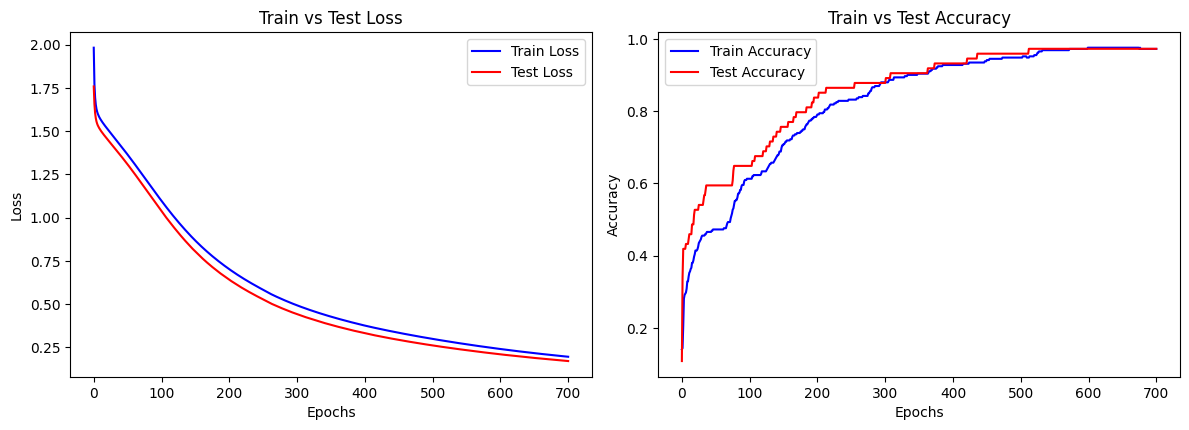

In [163]:
# Plotting the metrics
plt.figure(figsize=(12, 8))

# Plot loss and test loss
plt.subplot(2, 2, 1)
plt.plot(epochs_list, train_loss_list, label='Train Loss', color='blue')
plt.plot(epochs_list, test_loss_list, label='Test Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Train vs Test Loss')
plt.legend()

# Plot accuracy and test accuracy
plt.subplot(2, 2, 2)
plt.plot(epochs_list, train_acc_list, label='Train Accuracy', color='blue')
plt.plot(epochs_list, test_acc_list, label='Test Accuracy', color='red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Train vs Test Accuracy')
plt.legend()

plt.tight_layout()
plt.show()